Portfolio Construction and Tail Risk Diagnostics

In [243]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.optimize as sco

Step 1: Data Preparation

In [244]:
tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS','ITC.NS', 'HINDUNILVR.NS', 'BHARTIARTL.NS', 'LT.NS', 'TMPV.NS']

In [245]:
print("Historical data for 10 assets")

raw_data = yf.download(tickers, start='2021-01-01', end='2026-01-01', group_by='ticker')


data_dict = {}
for ticker in tickers:
    ticker_df = raw_data[ticker]
    if 'Adj Close' in ticker_df.columns:
        data_dict[ticker] = ticker_df['Adj Close']
    else:
        data_dict[ticker] = ticker_df['Close']

data = pd.DataFrame(data_dict).dropna()

Historical data for 10 assets


[*********************100%***********************]  10 of 10 completed


In [246]:
print("From Daily closing prices to daily log returns")

returns = np.log(data / data.shift(1)).dropna()

From Daily closing prices to daily log returns


In [247]:
print("Annualized Log Returns and Covariance Matrix")

n_assets = len(tickers)
annual_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

Annualized Log Returns and Covariance Matrix


In [248]:
print("Annualized Expected Returns:")
print(annual_returns)

Annualized Expected Returns:
RELIANCE.NS      0.113321
TCS.NS           0.041514
HDFCBANK.NS      0.078431
INFY.NS          0.076637
ICICIBANK.NS     0.197478
ITC.NS           0.179137
HINDUNILVR.NS    0.010884
BHARTIARTL.NS    0.295748
LT.NS            0.244717
TMPV.NS          0.141962
dtype: float64


Step 2: Portfolio Optimization

In [249]:
risk_free = .055

In [250]:
def port_performance(weights, returns, cov_matrix):
    
    port_return = np.sum(returns.mean() * weights) * 252
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_volatility

print("the above function gives portfolio expected returns and volatility as a function of weights")

the above function gives portfolio expected returns and volatility as a function of weights


In [251]:
def min_var(weights, returns, cov_matrix):
    return port_performance(weights, returns, cov_matrix)[1] ** 2

print("this is the objective function to be minimized")

this is the objective function to be minimized


In [252]:
def neg_sharp(weights, returns,cov_matrix,risk_free):
    p_ret, p_vol = port_performance(weights, returns, cov_matrix)
    return -(p_ret - risk_free) / p_vol


The below code defines the constraints and bound which are:-
1. Sum of weights=1
2. No Short Selling ( each weight is in between 0 and 1)
3. Initial weight vector, assignes equal weight to all securities.

In [253]:
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) 
print("portfolio weights sum to 1")

bounds = tuple((0, 1) for i in range(n_assets))
print("Each weight between 0 and 1")

init_weights = n_assets * [1.0 / n_assets]
print("inital weight vector")

portfolio weights sum to 1
Each weight between 0 and 1
inital weight vector


The below code executes the optimization.

    Solving for Global Minimun Variance Portfolio

In [254]:
result_gmv = sco.minimize(fun=min_var, x0=init_weights, args=(returns, cov_matrix), method='SLSQP', 
                                   bounds=bounds, constraints=constraints)

In [255]:
weights_gmv = result_gmv.x
ret_gmv , vol_gmv = port_performance(weights_gmv,returns,cov_matrix)

        Solving for the Maximum Sharpe Ratio

In [256]:
res_msr  = sco.minimize(neg_sharp, init_weights, args=(returns, cov_matrix, risk_free),
                       method='SLSQP', bounds=bounds, constraints=constraints)

In [257]:
weights_msr = res_msr.x
ret_msr, vol_msr = port_performance(weights_msr, returns, cov_matrix)

            Tracing the Efficient Frontier

In [258]:
target_returns = np.linspace(ret_gmv, annual_returns.max(), 50)
frontier_volatilities = []

for target in target_returns:
    constraints_frontier = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: port_performance(x, returns, cov_matrix)[0] - target}
    )
    res = sco.minimize(min_var, init_weights, args=(returns, cov_matrix),
                       method='SLSQP', bounds=bounds, constraints=constraints_frontier)
    if res.success:
        frontier_volatilities.append(np.sqrt(res.fun))
    else:
        frontier_volatilities.append(np.nan)

In [259]:
print('Final Output')

print("\nOptimized Portfolio Weights (Maximum Sharpe)")
for ticker, weight in zip(tickers, weights_msr):
    print(f"{ticker}: {weight:.2%}")

print("\nOptimized Portfolio Weights (Minimum Variance)")
for ticker, weight in zip(tickers, weights_gmv):
    print(f"{ticker}: {weight:.2%}")

Final Output

Optimized Portfolio Weights (Maximum Sharpe)
RELIANCE.NS: 0.00%
TCS.NS: 0.00%
HDFCBANK.NS: 0.00%
INFY.NS: 0.00%
ICICIBANK.NS: 7.24%
ITC.NS: 20.04%
HINDUNILVR.NS: 0.00%
BHARTIARTL.NS: 50.29%
LT.NS: 22.44%
TMPV.NS: 0.00%

Optimized Portfolio Weights (Minimum Variance)
RELIANCE.NS: 4.71%
TCS.NS: 17.29%
HDFCBANK.NS: 13.01%
INFY.NS: 0.00%
ICICIBANK.NS: 7.89%
ITC.NS: 18.78%
HINDUNILVR.NS: 22.60%
BHARTIARTL.NS: 12.48%
LT.NS: 3.25%
TMPV.NS: 0.00%


Step 3: Risk Tracking and Measurement

In [260]:
opt_weights = weights_msr

In [261]:
port_daily_returns = returns.dot(opt_weights)

In [262]:
print("Value at Risk using Historical Data:")

confidence_level = 0.95
var_95 = np.percentile(port_daily_returns, (1 - confidence_level) * 100)
print(var_95)

Value at Risk using Historical Data:
-0.01516941817873899


In [263]:
print("Expected Shortfall / Conditional VaR ")
es_95 = port_daily_returns[port_daily_returns <= var_95].mean()
print(es_95)

Expected Shortfall / Conditional VaR 
-0.022311151101874448


In [264]:
print("Downside Semi Variance")
mean_return = port_daily_returns.mean()
variance = np.var(port_daily_returns)
downside_returns = port_daily_returns[port_daily_returns < mean_return]
downside_semi_variance = np.sum((downside_returns - mean_return) ** 2) / len(port_daily_returns)


Downside Semi Variance


In [265]:
print("\n Tail-Risk Modules (Daily) ")
print(f"95% Value at Risk (VaR): {var_95:.2%}")
print(f"95% Expected Shortfall (ES): {es_95:.2%}")
print(f"Downside Semi-Variance: {downside_semi_variance:.6f}")
print(f"Downside Semi-Variance as a percentage of Variance: {downside_semi_variance/variance:.2%}")


 Tail-Risk Modules (Daily) 
95% Value at Risk (VaR): -1.52%
95% Expected Shortfall (ES): -2.23%
Downside Semi-Variance: 0.000055
Downside Semi-Variance as a percentage of Variance: 50.88%


Step 4: Visualization

            Visualizaion of the Efficient Frontier

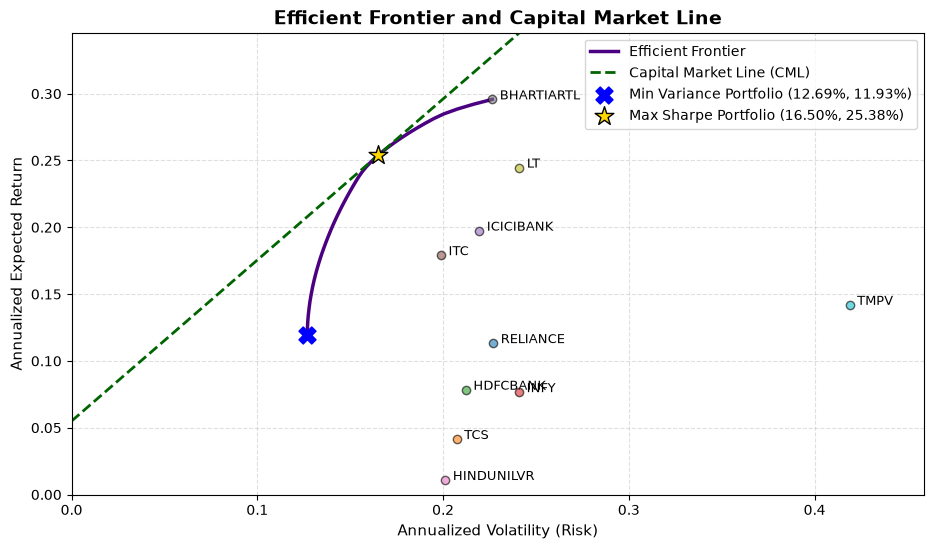

In [268]:
plt.figure(figsize=(11, 6))

# Efficient Frontier
plt.plot(frontier_volatilities, target_returns, color='indigo', linestyle='-', linewidth=2.5, label='Efficient Frontier')

# CML calculation
cml_slope = (ret_msr - risk_free) / vol_msr
max_plot_vol = max([np.sqrt(cov_matrix.iloc[i, i]) for i in range(n_assets)]) + 0.03
cml_x = np.linspace(0, max_plot_vol, 100)
cml_y = risk_free + cml_slope * cml_x
plt.plot(cml_x, cml_y, color='darkgreen', linestyle='--', linewidth=2, label='Capital Market Line (CML)')

# Key Portfolios
plt.scatter(vol_gmv, ret_gmv, color='blue', marker='X', s=150, zorder=5, label=f'Min Variance Portfolio ({vol_gmv:.2%}, {ret_gmv:.2%})')
plt.scatter(vol_msr, ret_msr, color='gold', marker='*', s=200, edgecolor='black', zorder=5, label=f'Max Sharpe Portfolio ({vol_msr:.2%}, {ret_msr:.2%})')

# 4.4 Scatter underlying assets & FIXED: dynamically capture all asset bounds
asset_volatilities = []
for i, ticker in enumerate(tickers):
    asset_vol = np.sqrt(cov_matrix.iloc[i, i])
    asset_ret = annual_returns.iloc[i]
    asset_volatilities.append(asset_vol)
    plt.scatter(asset_vol, asset_ret, alpha=0.6, edgecolors='black', zorder=4)
    plt.text(asset_vol + 0.004, asset_ret, ticker.split('.')[0], fontsize=9, zorder=4)

plt.title('Efficient Frontier and Capital Market Line', fontsize=14, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=11)
plt.ylabel('Annualized Expected Return', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

# FIXED: Extend the x-axis limits dynamically so highly volatile assets like TMPV fit inside the frame nicely
plt.xlim(0, max(asset_volatilities) + 0.04)
plt.ylim(0, max(target_returns) + 0.05)

plt.legend(loc='upper right', fontsize=10)
plt.show()

        Distribution for the Max Sharpe Portfolio

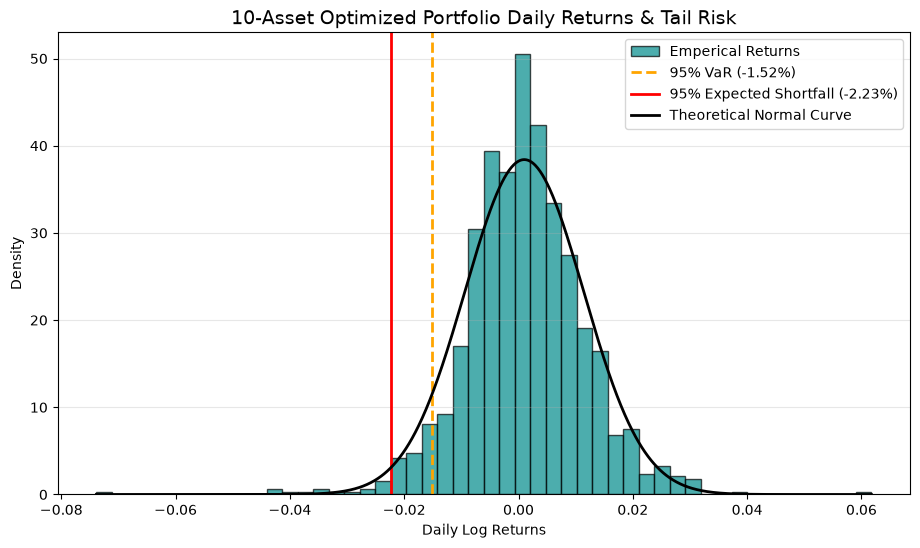

In [267]:
plt.figure(figsize=(11, 6))
plt.hist(port_daily_returns, bins=50, alpha=0.7,density=True ,color='darkcyan', edgecolor='black',label = "Emperical Returns")

plt.make_this_clean = True
plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'95% VaR ({var_95:.2%})')
plt.axvline(es_95, color='red', linestyle='-', linewidth=2, label=f'95% Expected Shortfall ({es_95:.2%})')


plt.title('10-Asset Optimized Portfolio Daily Returns & Tail Risk', fontsize=14)
plt.xlabel('Daily Log Returns')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)


# Now Fitting the theoritical normal distribution on the data.

from scipy.stats import norm
x = np.linspace(port_daily_returns.min(), port_daily_returns.max(),1000)
y = norm.pdf(x,mean_return,(variance)**0.5)

plt.plot(x, y, color='black', linestyle='-', linewidth=2, label='Theoretical Normal Curve')
plt.legend(loc='upper right')